### Standard linear regression on TracerX dataset

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load clinical data
cleaned_tx_by_nan = pd.read_csv("data/20221109_TRACERx421_all_patient_df_Converted.csv")
cleaned_tx_by_nan.columns = cleaned_tx_by_nan.columns.str.strip()

# Drop column 'Unnamed: 0' if it exists
if 'Unnamed: 0' in cleaned_tx_by_nan.columns:
    cleaned_tx_by_nan = cleaned_tx_by_nan.drop(columns=['Unnamed: 0'])
# Rename 'patient_id' to 'cruk_id' in cleaned_tx_by_nan
if 'patient_id' in cleaned_tx_by_nan.columns:
    cleaned_tx_by_nan = cleaned_tx_by_nan.rename(columns={'patient_id': 'cruk_id'})

print(f"Shape of TracerX Dataset: {cleaned_tx_by_nan.shape}")

Shape of TracerX Dataset: (421, 45)


In [4]:
# Let's use the relevant clinical features from cleaned_tx_by_nan
df_features = cleaned_tx_by_nan.copy()
# Print first few rows of 'cruk_id' in both dataframes for debugging
print("First few 'cruk_id' values in clinical features DataFrame:")
print(df_features['cruk_id'].head())
print(df_features['cruk_id'].size)

# Ensure 'cruk_id' exists in both DataFrames
if 'cruk_id' not in df_features.columns:
    raise KeyError("'cruk_id' column is missing in the clinical features DataFrame (tx_keep). Please check the input file.")

First few 'cruk_id' values in clinical features DataFrame:
0     32
1    107
2    109
3     87
4     43
Name: cruk_id, dtype: int64
421


In [5]:
# From TracerX dataset, we want to create a balanced dataset based on DFS time.
threshold_dfs_time = 365*3.5 # Set a threshold for DFS time (e.g., 3.5 year)

# Drop rows with missing dfs_time
tracerx_df = df_features.dropna(subset=['dfs_time'])

# Filter datasets
events_df = tracerx_df[tracerx_df['cens_dfs'] == 1]
non_events_df = tracerx_df[(tracerx_df['dfs_time'] > threshold_dfs_time) & (tracerx_df['cens_dfs'] == 0)]

print(f"Number of events: {len(events_df)}, Number of non-events: {len(non_events_df)}")

# Combine and label
combined_events_df = pd.concat([events_df, non_events_df], ignore_index=True)
combined_events_df['shorter_dfs_balanced'] = (combined_events_df['dfs_time'] < threshold_dfs_time).astype(int)

print(combined_events_df['shorter_dfs_balanced'].value_counts())
print(combined_events_df['shorter_dfs_balanced'].value_counts(normalize=True))

Number of events: 206, Number of non-events: 169
shorter_dfs_balanced
0    190
1    185
Name: count, dtype: int64
shorter_dfs_balanced
0    0.506667
1    0.493333
Name: proportion, dtype: float64


In [6]:
# Fill NaNs with mean (or other imputation strategy)
clinical_features = [c for c in combined_events_df.columns if c not in ['shorter_dfs_balanced']]
X_clinical = combined_events_df[clinical_features].values
y = combined_events_df['shorter_dfs_balanced'].values.astype(int)

X_clinical_clean = pd.DataFrame(X_clinical).fillna(pd.DataFrame(X_clinical).mean()).values
y_clean = pd.Series(y).fillna(pd.Series(y).mean()).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clinical_clean)


In [7]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_clean, test_size=0.2, random_state=42)

# Fit linear regression
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predict
y_pred = linreg.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression on clinical features:")
print(f"  MSE: {mse:.4f}")
print(f"  R2: {r2:.4f}")

Linear Regression on clinical features:
  MSE: 0.0352
  R2: 0.8570


### Bayesian linear regression on TracerX dataset

In [8]:
import pymc as pm

# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clinical_clean)

n_samples, n_features = X_scaled.shape

with pm.Model() as linear_model:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=5)
    beta = pm.Normal("beta", mu=0, sigma=2, shape=n_features)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Linear model
    mu = intercept + pm.math.dot(X_scaled, beta)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_clean)

    # Sample from posterior
    trace_lin = pm.sample(2000, tune=1000, target_accept=0.95, random_seed=42, cores=4)

with linear_model:
    post_pred = pm.sample_posterior_predictive(trace_lin, var_names=["y_obs"], random_seed=42, return_inferencedata=False)

y_pred_samples = post_pred["y_obs"]  # shape (n_draws, n_samples)

# Compute mean predictions
y_pred_mean = y_pred_samples.mean(axis=0)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 135 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Sampling: [y_obs]


Output()

In [9]:
print("y_pred_samples shape:", y_pred_samples.shape)
print("y_pred_samples shape:", y_pred_samples.shape)
print("y_clean shape:", y_clean.shape)

y_pred_samples shape: (4, 2000, 375)
y_pred_samples shape: (4, 2000, 375)
y_clean shape: (375,)


In [10]:
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

mse_samples = ((y_pred_samples - y_clean) ** 2).mean(axis=1)

# Collapse chains and draws -> (8000, 375)
y_pred_samples_flat = y_pred_samples.reshape(-1, y_pred_samples.shape[-1])

# Compute R² for each posterior draw
r2_samples = [
    r2_score(y_clean, y_pred_samples_flat[i, :])
    for i in range(y_pred_samples_flat.shape[0])
]

r2_samples = np.array(r2_samples)

# Posterior predictive mean
y_pred_mean = y_pred_samples_flat.mean(axis=0)
r2_mean = r2_score(y_clean, y_pred_mean)

print("Bayesian Linear Regression (Clinical Features):")
metrics_summary = pd.DataFrame([
    {
        "Metric": "R²",
        "Posterior Mean": r2_mean,
        "Mean (across draws)": r2_samples.mean(),
        "95%_CI_low": np.percentile(r2_samples, 3),
        "95%_CI_high": np.percentile(r2_samples, 97),
    },
    {
        "Metric": "MSE",
        "Posterior Mean": mse_samples,
        "Mean (across draws)": mse_samples.mean(),
        "95%_CI_low": np.percentile(mse_samples, 3),
        "95%_CI_high": np.percentile(mse_samples, 97),
    }
])

print(f"  MSE: {mse_samples.mean():.4f}")
print(f"  R2: {r2_mean.mean():.4f}")
print(metrics_summary)

Bayesian Linear Regression (Clinical Features):
  MSE: 0.0496
  R2: 0.9132
  Metric                                     Posterior Mean  \
0     R²                                            0.91316   
1    MSE  [[0.27532206626103706, 0.034674351762872924, 0...   

   Mean (across draws)  95%_CI_low  95%_CI_high  
0             0.801659    0.771363     0.828891  
1             0.049576    0.025899     0.199412  


### Random Forest Regression on TracerX datasets

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# Train/test split for Random Forest Regressor
X_train, X_test, y_train, y_test = train_test_split(
    X_clinical_clean, y_clean, test_size=0.2, random_state=42
)

# Train Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=500,   # number of trees
    max_depth=None,     # no limit on depth
    random_state=42,
    n_jobs=-1           # use all cores
)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

metrics_rf = pd.DataFrame([{
    "Model": "Random Forest (Clinical Only)",
    "R²": r2,
    "MSE": mse
}])

print(metrics_rf)

                           Model        R²       MSE
0  Random Forest (Clinical Only)  0.958094  0.010326


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# Define model
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Use K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []
mse_scores = []

for train_idx, test_idx in kf.split(X_clinical_clean):
    X_train, X_test = X_clinical_clean[train_idx], X_clinical_clean[test_idx]
    y_train, y_test = y_clean[train_idx], y_clean[test_idx]
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    r2_scores.append(r2_score(y_test, y_pred))
    mse_scores.append(mean_squared_error(y_test, y_pred))

# Convert to arrays
r2_scores = np.array(r2_scores)
mse_scores = np.array(mse_scores)

# Summarize
rf_metrics_summary = pd.DataFrame([
    {
        "Model": "Random Forest (Clinical Only)",
        "Metric": "R²",
        "Mean": r2_scores.mean(),
        "95%_CI_low": np.percentile(r2_scores, 3),
        "95%_CI_high": np.percentile(r2_scores, 97)
    },
    {
        "Model": "Random Forest (Clinical Only)",
        "Metric": "MSE",
        "Mean": mse_scores.mean(),
        "95%_CI_low": np.percentile(mse_scores, 3),
        "95%_CI_high": np.percentile(mse_scores, 97)
    }
])

print(rf_metrics_summary)


                           Model Metric      Mean  95%_CI_low  95%_CI_high
0  Random Forest (Clinical Only)     R²  0.991670    0.963765     0.999981
1  Random Forest (Clinical Only)    MSE  0.002053    0.000005     0.008928


### Random Forest Regression on Newick TreeLSTM and TracerX datasets

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt

# Load embeddings and clinical data
emb = pd.read_csv("patient_embeddings_with_labels.csv")  # TreeLSTM embeddings
cleaned_tx_by_nan = pd.read_csv("data/20221109_TRACERx421_all_patient_df_Converted.csv")
cleaned_tx_by_nan.columns = cleaned_tx_by_nan.columns.str.strip()

# Drop column 'Unnamed: 0' if it exists
if 'Unnamed: 0' in cleaned_tx_by_nan.columns:
    cleaned_tx_by_nan = cleaned_tx_by_nan.drop(columns=['Unnamed: 0'])
# Rename 'patient_id' to 'cruk_id' in cleaned_tx_by_nan
if 'patient_id' in cleaned_tx_by_nan.columns:
    cleaned_tx_by_nan = cleaned_tx_by_nan.rename(columns={'patient_id': 'cruk_id'})

print(f"Shape of TracerX Dataset: {cleaned_tx_by_nan.shape}")
print(f"Shape of TreeLSTM Dataset: {emb.shape}")

# Convert numeric IDs to CRUK format (zero-padded 4 digits)
cleaned_tx_by_nan['cruk_id'] = cleaned_tx_by_nan['cruk_id'].astype(str).str.zfill(4)
cleaned_tx_by_nan['cruk_id'] = "CRUK" + cleaned_tx_by_nan['cruk_id']

# Let's use the relevant clinical features from cleaned_tx_by_nan
tx_keep = cleaned_tx_by_nan.copy()

# Print first few rows of 'cruk_id' in both dataframes for debugging
print("First few 'cruk_id' values in TreeLSTM DataFrame:")
print(emb['cruk_id'].head())
print(emb.shape)
print("First few 'cruk_id' values in TracerX DataFrame:")
print(tx_keep['cruk_id'].head())
print(tx_keep.shape)

# Merge embeddings with clinical features
df_features = emb.merge(tx_keep, on='cruk_id', how='inner')
print(f"Columns in merged DataFrame (df_features): {len(df_features.columns)}")
print(f"Shape of merged DataFrame (df_features): {df_features.shape}")
print(f"Columns in df_features (merged on cruk_id): {emb.shape[1]} + {tx_keep.shape[1] - 1} = {df_features.shape[1]}")


Shape of TracerX Dataset: (421, 45)
Shape of TreeLSTM Dataset: (339, 34)
First few 'cruk_id' values in TreeLSTM DataFrame:
0    CRUK0005
1    CRUK0057
2    CRUK0039
3    CRUK0196
4    CRUK0023
Name: cruk_id, dtype: object
(339, 34)
First few 'cruk_id' values in TracerX DataFrame:
0    CRUK0032
1    CRUK0107
2    CRUK0109
3    CRUK0087
4    CRUK0043
Name: cruk_id, dtype: object
(421, 45)
Columns in merged DataFrame (df_features): 78
Shape of merged DataFrame (df_features): (201, 78)
Columns in df_features (merged on cruk_id): 34 + 44 = 78


In [17]:
# Train/test split for Random Forest Regressor
tree_cols = [str(i) for i in range(32)]

# Automatically select all clinical columns
clinical_cols = [c for c in df_features.columns if c not in tree_cols + ['cruk_id', 'dfs_time', 'cens_dfs', 'shorter_dfs_balanced']]

# Prepare feature matrix
X = df_features[tree_cols + clinical_cols]
y = df_features['shorter_dfs_balanced'].values 

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Regressor MSE: {mse:.4f}")
print(f"Random Forest Regressor R²: {r2:.4f}")

# Feature importance
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importances.head(15))

Random Forest Regressor MSE: 0.2528
Random Forest Regressor R²: -0.0165
                       feature  importance
45  size_pathology_per_patient    0.040992
37                   packyears    0.040945
32                         age    0.038421
2                            2    0.037983
5                            5    0.037610
35                 cigs_perday    0.036129
7                            7    0.032868
18                          18    0.032707
36               years_smoking    0.030877
11                          11    0.027693
30                          30    0.027549
24                          24    0.027229
70             lung_event_time    0.025754
1                            1    0.025190
66                     os_time    0.025120


SHAP values shape: (41, 74)


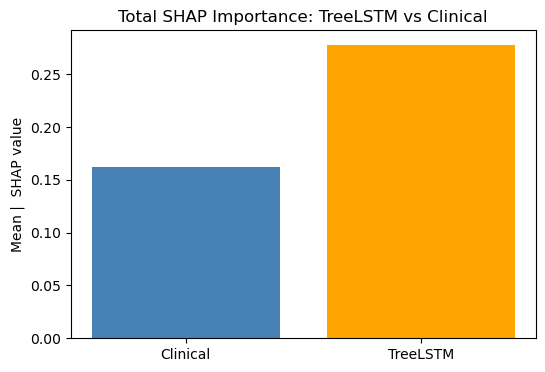

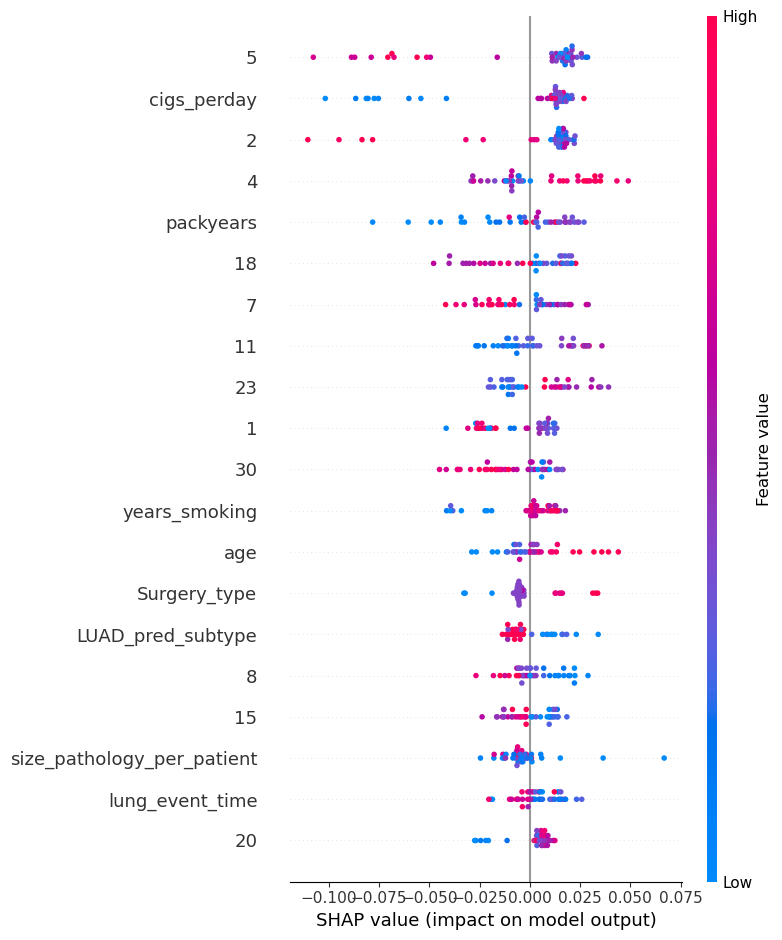

In [19]:
import shap
import matplotlib.pyplot as plt

# SHAP analysis
explainer = shap.TreeExplainer(rf)
shap_exp = explainer(X_test)  # returns Explanation object

# Extract SHAP values
shap_values = shap_exp.values  # shape: (n_samples, n_features) or (n_samples, n_features, n_classes)

# Handle binary/multi-class
if shap_values.ndim == 3:  # multi-class
    # For binary classification, pick the positive class automatically
    if shap_values.shape[2] == 2:
        shap_values = shap_values[:, :, 1]  # positive class
    else:
        # For >2 classes, you could either pick a class or sum/average across classes
        shap_values = shap_values.mean(axis=2)  # average SHAP across classes


# Check shapes
print("SHAP values shape:", shap_values.shape)

# Per-feature importance
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": np.abs(shap_values).mean(axis=0)
})
importance_df["group"] = importance_df["feature"].apply(
    lambda f: "TreeLSTM" if f in tree_cols else "Clinical"
)

# Group-level plot
plt.figure(figsize=(6,4))
group_importance = importance_df.groupby("group")["importance"].sum().reset_index()
plt.bar(group_importance["group"], group_importance["importance"], color=["steelblue","orange"])
plt.title("Total SHAP Importance: TreeLSTM vs Clinical")
plt.ylabel("Mean |  SHAP value")
plt.show()

# Detailed per-feature SHAP summary
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

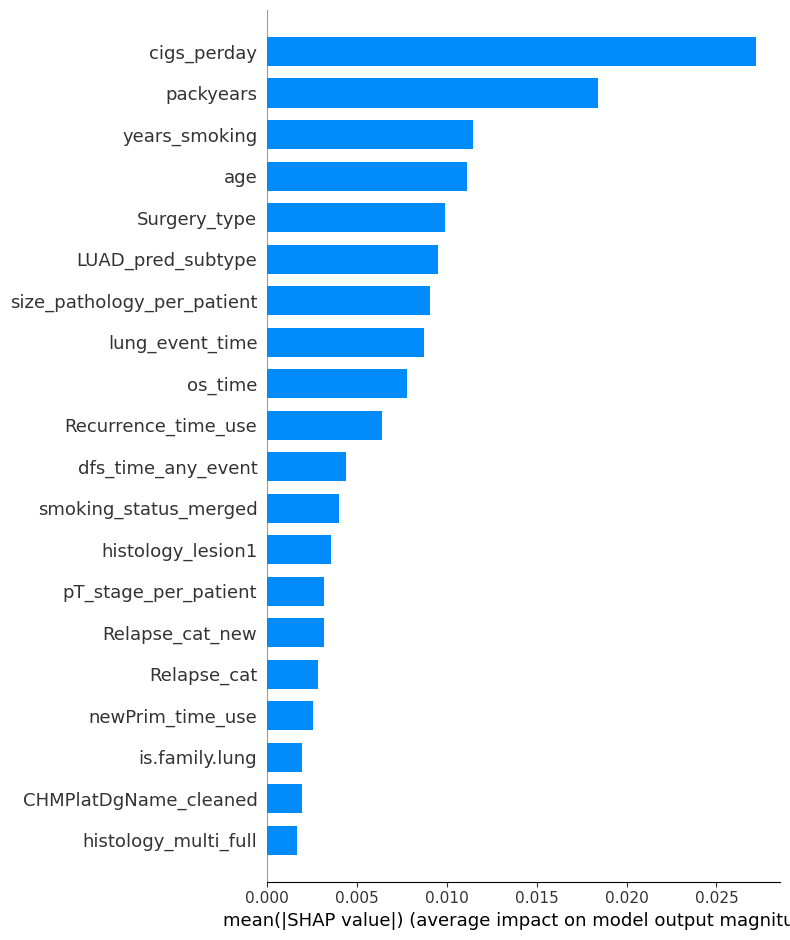

In [20]:
# Clinical features only
X_test_clinical = X_test[clinical_cols]
shap_values_clinical = shap_values[:, [X_test.columns.get_loc(f) for f in clinical_cols]]

# Summary plot for clinical features
shap.summary_plot(
    shap_values_clinical, 
    X_test_clinical, 
    feature_names=clinical_cols,
    plot_type="bar"
)

### Most Important Features


In [21]:
print("SHAP analysis completed successfully.")
# Print the top features by importance
top_features = importance_df.sort_values(by="importance", ascending=False).head(10)
print("Top features by SHAP importance:")
print(top_features)


SHAP analysis completed successfully.
Top features by SHAP importance:
        feature  importance     group
5             5    0.031662  TreeLSTM
35  cigs_perday    0.027176  Clinical
2             2    0.023277  TreeLSTM
4             4    0.019264  TreeLSTM
37    packyears    0.018418  Clinical
18           18    0.016992  TreeLSTM
7             7    0.015748  TreeLSTM
11           11    0.015324  TreeLSTM
23           23    0.015167  TreeLSTM
1             1    0.014711  TreeLSTM


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 10 seconds.
There were 8000 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_obs]


Output()

Shape of posterior predictive samples: (2050, 160)
                        Model    Metric      Mean  95%_CI_low  95%_CI_high
0  Bayesian Linear Regression  Accuracy  0.502716    0.481250     0.531250
1  Bayesian Linear Regression       AUC  0.499977    0.475621     0.525629
2  Bayesian Linear Regression        F1  0.221937    0.024096     0.661088
3               Random Forest       MSE  0.252756         NaN          NaN
4               Random Forest        R² -0.016466         NaN          NaN


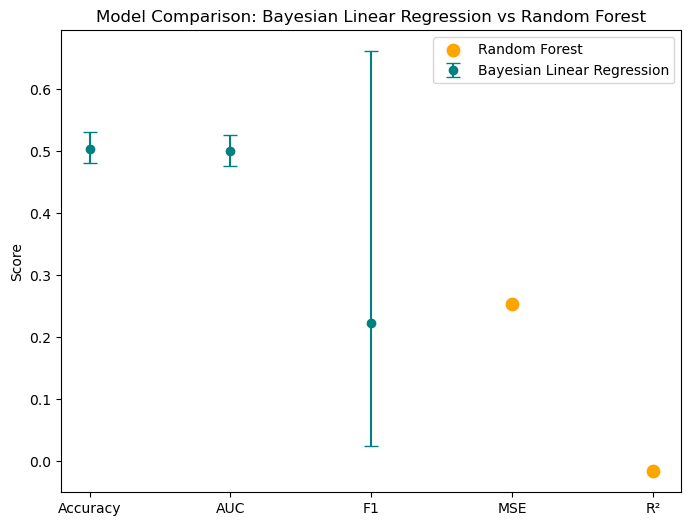

In [25]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler

# Bayesian Linear Regression
# Select top 10 features for test to reduce dimensionality
top_features = importance_df.sort_values("importance", ascending=False)["feature"].iloc[:10].tolist()
X_top = df_features[top_features]  # Use only top 10 features
y = df_features['shorter_dfs_balanced'].values 

# Standardize features
X_scaled = StandardScaler().fit_transform(X)
n_features = X_scaled.shape[1]

# Fill NaNs with 0 or mean
X_clean = X_test.fillna(0)

# Use cleaned features (imputed or dropped NaNs)
X_bayes = X_clean.values  # shape (n_samples, n_features)
y_bayes = y_test  # shape (n_samples,)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bayes)

n_samples, n_features = X_scaled.shape

n_features = X_bayes.shape[1]

with pm.Model() as linear_model:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=5)
    beta = pm.Normal("beta", mu=0, sigma=2, shape=n_features)
    
    # Logistic regression
    logits = intercept + pm.math.dot(X_bayes, beta)
    p = pm.math.sigmoid(logits)
    
    # Likelihood
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y_bayes)
    
    # Sample from posterior
    trace = pm.sample(
        2000,
        tune=1000,
        target_accept=0.95,
        random_seed=42,
        cores=4
    )

X_bayes_scaled = scaler.fit_transform(X_train[top_features].fillna(0).values)
y_bayes = y_train

# Posterior predictive
with linear_model:
    post_pred = pm.sample_posterior_predictive(trace, var_names=["y_obs"], random_seed=42, return_inferencedata=False)

y_pred_samples = post_pred["y_obs"].reshape(-1, y_bayes.shape[0])

print(f"Shape of posterior predictive samples: {y_pred_samples.shape}")
# y_pred_samples has shape (n_draws, n_train_samples)
accs, aucs, f1s = [], [], []

for y_sample in y_pred_samples:  # y_sample shape: (n_train_samples,)
    accs.append(accuracy_score(y_bayes, y_sample))
    aucs.append(roc_auc_score(y_bayes, y_sample))
    f1s.append(f1_score(y_bayes, y_sample))

accs = np.array(accs)
aucs = np.array(aucs)
f1s = np.array(f1s)

def summarize_metric(values):
    return {
        "mean": values.mean(),
        "hdi_3%": np.percentile(values, 3),
        "hdi_97%": np.percentile(values, 97)
    }

acc_summary = summarize_metric(accs)
auc_summary = summarize_metric(aucs)
f1_summary = summarize_metric(f1s)

bayes_metrics = pd.DataFrame({
    "Model": ["Bayesian Linear Regression"]*3,
    "Metric": ["Accuracy", "AUC", "F1"],
    "Mean": [acc_summary["mean"], auc_summary["mean"], f1_summary["mean"]],
    "95%_CI_low": [acc_summary["hdi_3%"], auc_summary["hdi_3%"], f1_summary["hdi_3%"]],
    "95%_CI_high": [acc_summary["hdi_97%"], auc_summary["hdi_97%"], f1_summary["hdi_97%"]],
})

# Random Forest
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)
# Predicted labels on test set
y_pred_rf = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

rf_metrics = pd.DataFrame({
    "Model": ["Random Forest"]*2,
    "Metric": ["MSE", "R²"],
    "Mean": [mse, r2],
})

# Display metrics for both models
metrics_comparison = pd.concat([bayes_metrics, rf_metrics], ignore_index=True)
print(metrics_comparison)
# Plotting comparison of Bayesian Logistic Regression vs Random Forest
plt.figure(figsize=(8,6))

# Plot Bayesian with error bars
bayes_subset = metrics_comparison[metrics_comparison["Model"]=="Bayesian Linear Regression"]
plt.errorbar(
    bayes_subset["Metric"], bayes_subset["Mean"],
    yerr=[bayes_subset["Mean"]-bayes_subset["95%_CI_low"], 
          bayes_subset["95%_CI_high"]-bayes_subset["Mean"]],
    fmt="o", capsize=5, label="Bayesian Linear Regression", color="teal"
)

# Plot Random Forest (point estimates)
rf_subset = metrics_comparison[metrics_comparison["Model"]=="Random Forest"]
plt.scatter(rf_subset["Metric"], rf_subset["Mean"], label="Random Forest", color="orange", s=80)

plt.ylabel("Score")
plt.title("Model Comparison: Bayesian Linear Regression vs Random Forest")
plt.legend()
plt.show()
